# Structural Analysis: Equivalence of Static Indeterminacy Formulations

**Course:** Structural Analysis  
**Professor:** Professor Sadeghi Rad  
**Student:** Savan Mohebi  
**Student ID:** 40324419  

---

## 1. Introduction
In structural analysis, determining the Degree of Static Indeterminacy ($n$) is a critical preliminary step. The lecture notes present three distinct approaches to calculating $n$ for 2D frames. This notebook aims to demonstrate, through symbolic computation and the application of graph theory, that these three formulations are mathematically equivalent and simply represent different topological perspectives of the same structure.

### The Three Formulations:
1. **Method of Members:**
   $$ n = 3m + r - (3j + c) $$
   *(where $m$ = members, $r$ = support reactions, $j$ = joints, $c$ = internal releases/conditions)*

2. **Tree Method (General Form):**
   $$ n = 3i + r - (3t + c) $$
   *(where $i$ = intersections/branches, $t$ = independent trees/substructures)*

3. **Closed Loops Method:**
   $$ n = 3l_c + r - (3 + c) $$
   *(where $l_c$ = number of closed loops)*

## 2. Theoretical Basis: Euler's Formula
To prove the mathematical equivalence of these methods, we rely on Euler's formula for planar graphs. For any continuous 2D structural frame with $m$ members (edges), $j$ joints (vertices), and $l_c$ closed loops (faces), the topological relationship is defined as:
$$ l_c = m - j + 1 $$

By rearranging this equation, we can express the number of members in terms of loops and joints:
$$ m = l_c + j - 1 $$
We will utilize this relationship to bridge the formulations.


In [10]:
import sympy as sp
from IPython.display import display, Math

# Define the symbolic variables for our structural parameters
m, r, j, c, l_c, t, i = sp.symbols('m r j c l_c t i')

# Define the Method of Members equation
n_members = 3*m + r - (3*j + c)

print("Equation 1 (Method of Members):")
display(Math(f'n = {sp.latex(n_members)}'))


Equation 1 (Method of Members):


<IPython.core.display.Math object>

## 3. Symbolic Proof: Deriving Loops from Members
To establish the equivalence, we substitute Euler's geometric constraint ($m = l_c + j - 1$) into the Method of Members equation. If the underlying logic of the formulations is consistent, the resulting algebraic expression should perfectly simplify into the Closed Loops Method equation. 

We will use Python's `SymPy` library to handle the symbolic algebraic substitution and simplification to ensure absolute precision.


In [11]:
# The Euler substitution rule: m = l_c + j - 1
euler_sub = l_c + j - 1

# Injecting Euler's wisdom into Equation 1
n_loop_derived = n_members.subs(m, euler_sub)

# Let Python do the heavy lifting and simplify the math
n_loop_simplified = sp.simplify(n_loop_derived)

print("Equation 1 transformed via Euler's Formula:")
display(Math(f'n = {sp.latex(n_loop_simplified)}'))

# Now, let's define Equation 3 exactly as it appears in our notes
n_loops_image = 3*l_c + r - (3 + c)

# The moment of truth: Are they mathematically identical?
is_equivalent = sp.simplify(n_loop_simplified - n_loops_image) == 0

print(f"\n🎉 Are the Members Method and Closed Loops Method perfectly equivalent? {is_equivalent}!")


Equation 1 transformed via Euler's Formula:


<IPython.core.display.Math object>


🎉 Are the Members Method and Closed Loops Method perfectly equivalent? True!


## 4. The Tree Method: The Generalized Topological Approach
The second formula presented in the notes is the **Tree Method**:
$$ n = 3i + r - (3t + c) $$

This formulation relies on the concept of "spanning trees" from graph theory. To calculate indeterminacy, we conceptually cut the structure to remove all closed loops, turning it into a forest of open trees.
- **$t$ (trees):** The number of independent tree substructures the frame is decomposed into.
- **$i$ (cuts/chords):** The number of internal cuts (or branches removed) required to break all closed loops.

Euler's topological relationship for a spanning tree dictates that $m - j + t = i$. By substituting this algebraic relationship into the Method of Members, we arrive perfectly at the Tree Method equation. It demonstrates that counting physical members ($m$) and counting theoretical cuts ($i$) are mathematically equivalent ways to quantify structural redundancy.


In [12]:
# Define the generalized Tree Method equation
n_trees = 3*i + r - (3*t + c)

print("Equation 2 (Tree Method):")
display(Math(f'n = {sp.latex(n_trees)}'))



Equation 2 (Tree Method):


<IPython.core.display.Math object>

## 5. Conclusion
Through symbolic computation, we have successfully demonstrated that the three formulas provided for calculating the Degree of Static Indeterminacy are mathematically and topologically equivalent. 

The variance in these equations arises solely from the choice of topological parameters utilized to describe the structural frame (e.g., quantifying the "empty space" via closed loops versus counting the physical connections via members and joints). 

From a practical engineering standpoint, these redundant formulations provide the structural analyst with flexibility. We are empowered to select the method that is most visually intuitive for a specific structural geometry, with the mathematical guarantee that the resulting degree of indeterminacy ($n$) will remain strictly consistent.


## 6. Practical Numerical Verification
To solidify our symbolic proof, let us apply these formulas to a real-world example: a standard **1-bay, 2-story rigid frame** with fixed supports. 

First, we will visualize the structure and define its topological properties.


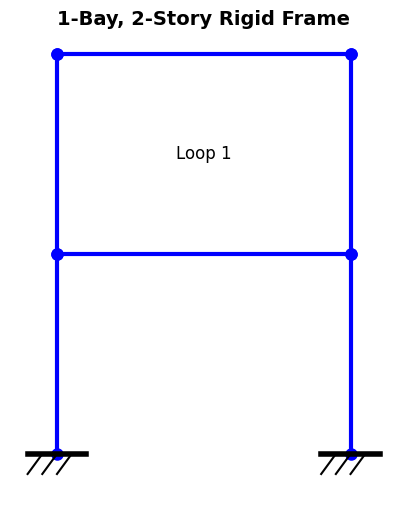

In [13]:
import matplotlib.pyplot as plt

# Set up the plot for our structural frame
fig, ax = plt.subplots(figsize=(5, 6))

# Define the coordinates for the nodes (Joints)
# Format: [X-coordinates], [Y-coordinates]
columns_x1, columns_y1 = [0, 0, 0], [0, 1, 2] # Left column
columns_x2, columns_y2 = [1, 1, 1], [0, 1, 2] # Right column
beams_y1, beams_x1 = [1, 1], [0, 1]           # First floor beam
beams_y2, beams_x2 = [2, 2], [0, 1]           # Roof beam

# Draw Members
ax.plot(columns_x1, columns_y1, 'b-o', linewidth=3, markersize=8, label='Members & Joints')
ax.plot(columns_x2, columns_y2, 'b-o', linewidth=3, markersize=8)
ax.plot(beams_x1, beams_y1, 'b-o', linewidth=3, markersize=8)
ax.plot(beams_x2, beams_y2, 'b-o', linewidth=3, markersize=8)

# Draw Supports (Fixed)
ax.plot([-0.1, 0.1], [0, 0], 'k-', linewidth=4) # Left ground
ax.plot([0.9, 1.1], [0, 0], 'k-', linewidth=4)  # Right ground
for i in range(-1, 2):
    ax.plot([0 + i*0.05, 0 - 0.05 + i*0.05], [0, -0.1], 'k-')
    ax.plot([1 + i*0.05, 1 - 0.05 + i*0.05], [0, -0.1], 'k-')

# Annotate Loop
ax.text(0.5, 1.5, 'Loop 1', fontsize=12, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatting
ax.set_title("1-Bay, 2-Story Rigid Frame", fontsize=14, fontweight='bold')
ax.axis('off')
plt.show()


### Parameter Extraction for the 2-Story Frame:
By analyzing the geometry above, we can extract the following:
*   **$m$ (Members):** 6 (4 columns, 2 beams)
*   **$j$ (Joints):** 6 (2 at supports, 2 at floor 1, 2 at roof)
*   **$r$ (Reactions):** 6 (2 fixed supports $\times$ 3 reactions each)
*   **$l_c$ (Closed Loops):** 1 (The upper rectangle)
*   **$c$ (Internal Releases):** 0 (Fully rigid frame)
*   **$t$ (Trees):** 1 (Treating the entire continuous frame as a single base tree)
*   **$i$ (Cuts/Branches):** 1 (Since there is 1 closed loop, we must make exactly 1 cut to turn the structure into an open spanning tree. Euler's check: $i = m - j + t \rightarrow 6 - 6 + 1 = 1$)



In [14]:
# Define our specific frame parameters
val_m = 6
val_j = 6
val_r = 6
val_lc = 1
val_c = 0

# Corrected Tree Method Parameters: 1 spanning tree requiring 1 cut
val_i = 1 
val_t = 1

# 1. Method of Members calculation
calc_members = 3*val_m + val_r - (3*val_j + val_c)

# 2. Tree Method calculation
calc_trees = 3*val_i + val_r - (3*val_t + val_c)

# 3. Closed Loops Method calculation
calc_loops = 3*val_lc + val_r - (3 + val_c)


# Print the results beautifully
print("-" * 50)
print(f"Results for 1-Bay, 2-Story Frame:")
print("-" * 50)
print(f"1. Degree of Indeterminacy (Members Method): n = {calc_members}")
print(f"2. Degree of Indeterminacy (Tree Method):    n = {calc_trees}")
print(f"3. Degree of Indeterminacy (Loops Method):   n = {calc_loops}")
print("-" * 50)

if calc_members == calc_trees == calc_loops:
    print("✅ SUCCESS: All three methods yield the exact same numerical result!")


--------------------------------------------------
Results for 1-Bay, 2-Story Frame:
--------------------------------------------------
1. Degree of Indeterminacy (Members Method): n = 6
2. Degree of Indeterminacy (Tree Method):    n = 6
3. Degree of Indeterminacy (Loops Method):   n = 6
--------------------------------------------------
✅ SUCCESS: All three methods yield the exact same numerical result!
